# Slum Detection — Sentinel-2 DKI Jakarta

Pipeline: Eksplorasi Data → Preprocessing → Training U-Net → Evaluasi Spatial CV → Interpretasi

Dataset: 140 citra slum + 261 non-slum (GeoTIFF, 6 band, ~10m/px, EPSG:4326)  
Label: GeoJSON polygon per kelurahan/RW  
Task: Semantic segmentation biner (slum=1, non-slum=0)

In [24]:
%matplotlib inline
import os, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, jaccard_score, accuracy_score
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Band order: B2=0, B3=1, B4=2, B8=3, B11=4, B12=5
DATA_DIR     = Path('../dataset')
SLUM_DIR     = DATA_DIR / 'images' / 'slum'
NSLUM_DIR    = DATA_DIR / 'images' / 'non_slum'
PATCH_DIR    = DATA_DIR / 'patches'
PATCH_SIZE   = 256
STRIDE       = 128
VALID_THRESH = 0.30
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
print(sys.executable)

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

e:\competition\Hackathon-ML\.venv\Scripts\python.exe
Device: cuda
PyTorch: 2.6.0+cu124


## 1. Eksplorasi Data

In [25]:
gdf_slum   = gpd.read_file(DATA_DIR / 'labels' / 'dki_slum.geojson')
gdf_nslum  = gpd.read_file(DATA_DIR / 'labels' / 'dki_non_slum.geojson')
slum_files  = sorted(SLUM_DIR.glob('*.tif'))
nslum_files = sorted(NSLUM_DIR.glob('*.tif'))

print(f'Slum images   : {len(slum_files)}')
print(f'Non-slum images: {len(nslum_files)}')
print(f'Slum GeoJSON  : {len(gdf_slum)} rows | CRS: {gdf_slum.crs}')
print(f'Non-slum GeoJSON: {len(gdf_nslum)} rows | CRS: {gdf_nslum.crs}')

with rasterio.open(slum_files[0]) as src:
    sample_img = src.read().astype(np.float32)
    print(f'\nSample TIF ({slum_files[0].name}):')
    print(f'  Bands    : {src.count}  [B2, B3, B4, B8, B11, B12]')
    print(f'  Shape    : {src.height} x {src.width}')
    print(f'  CRS      : {src.crs}')
    print(f'  Resolusi : ~{src.res[0]*111320:.1f} m/pixel')
    print(f'  NoData   : {src.nodata}')
    print(f'  Val range: [{sample_img[sample_img>0].min():.4f}, {sample_img.max():.4f}]')

# Ukuran bervariasi — penting untuk strategi patch
sizes = []
for f in slum_files + nslum_files:
    with rasterio.open(f) as src:
        sizes.append((src.height, src.width))
sizes_arr = np.array(sizes)
print(f'\nUkuran TIF (H x W):')
print(f'  Min: {sizes_arr[:,0].min()} x {sizes_arr[:,1].min()}')
print(f'  Max: {sizes_arr[:,0].max()} x {sizes_arr[:,1].max()}')
print(f'  Median: {int(np.median(sizes_arr[:,0]))} x {int(np.median(sizes_arr[:,1]))}')
print(f'  < 256 di minimal 1 dimensi: {(np.min(sizes_arr, axis=1) < 256).sum()} file')

print(f'\nNilai [0,1] → Level-2A surface reflectance sudah ternormalisasi.')
print('Koreksi atmosfer: DILEWATI | Normalisasi: DILEWATI | Resampling: DILEWATI (semua 10m)')

Slum images   : 140
Non-slum images: 261
Slum GeoJSON  : 140 rows | CRS: EPSG:4326
Non-slum GeoJSON: 261 rows | CRS: EPSG:4326

Sample TIF (SLUM_ANCOL_RW_01_ID86.tif):
  Bands    : 6  [B2, B3, B4, B8, B11, B12]
  Shape    : 173 x 154
  CRS      : EPSG:4326
  Resolusi : ~10.0 m/pixel
  NoData   : 0.0
  Val range: [0.0142, 0.6689]

Ukuran TIF (H x W):
  Min: 12 x 9
  Max: 549 x 1105
  Median: 135 x 139
  < 256 di minimal 1 dimensi: 359 file

Nilai [0,1] → Level-2A surface reflectance sudah ternormalisasi.
Koreksi atmosfer: DILEWATI | Normalisasi: DILEWATI | Resampling: DILEWATI (semua 10m)


### 1.1 Cloud Check — Inspeksi Visual

SCL band tidak tersedia di dataset ini. Inspeksi dilakukan secara visual pada sampel representatif.
Perhatikan area putih/abu terang yang tidak sesuai dengan pola urban — indikasi awan.

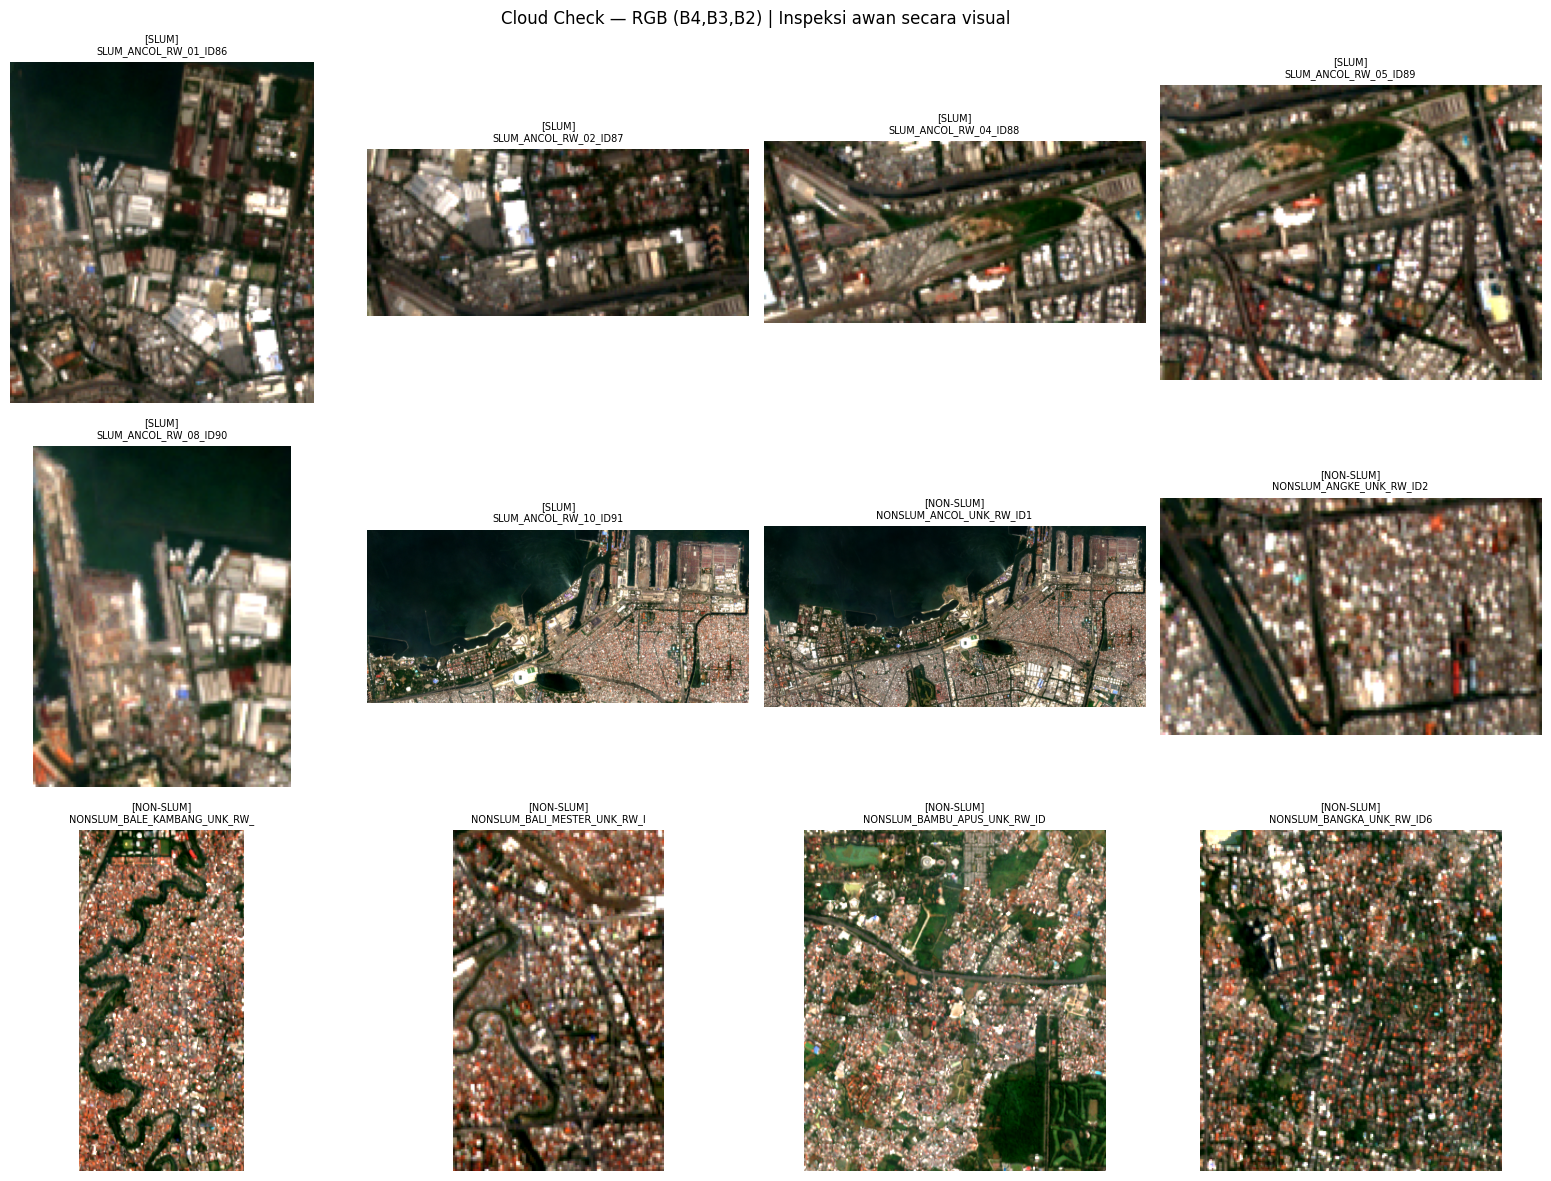

In [26]:
def rgb_stretch(img):
    """Percentile stretch B4,B3,B2 → display RGB."""
    rgb = img[[2, 1, 0]].copy()
    valid = rgb[rgb > 0]
    if len(valid) == 0:
        return np.zeros((*rgb.shape[1:], 3))
    p2, p98 = np.percentile(valid, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)
    return rgb.transpose(1, 2, 0)

sample_s  = slum_files[:6]
sample_ns = nslum_files[:6]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, (ax, fpath) in enumerate(zip(axes.ravel(), sample_s + sample_ns)):
    with rasterio.open(fpath) as src:
        img = src.read().astype(np.float32)
    lbl = 'SLUM' if i < 6 else 'NON-SLUM'
    ax.imshow(rgb_stretch(img))
    ax.set_title(f'[{lbl}]\n{fpath.stem[:28]}', fontsize=7)
    ax.axis('off')

plt.suptitle('Cloud Check — RGB (B4,B3,B2) | Inspeksi awan secara visual', fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 Distribusi Dataset

=== Distribusi Slum per Kecamatan ===
KEC_NAME
PENJARINGAN         17
CILINCING           16
TANAH ABANG         12
JOHAR BARU          11
SAWAH BESAR         10
TANJUNG PRIOK       10
KEBAYORAN BARU       9
PADEMANGAN           9
MAMPANG PRAPATAN     8
KOJA                 7
MENTENG              5
TEBET                5
KEBAYORAN LAMA       4
SENEN                3
PASAR MINGGU         3
SETIA BUDI           3
KELAPA GADING        3
GAMBIR               2
CILANDAK             2
PESANGGRAHAN         1

Total kecamatan slum: 20

=== Distribusi Non-Slum per Kecamatan ===
Kecamatan
TAMBORA              11
KEBAYORAN BARU       10
JATINEGARA            8
CIPAYUNG              8
KEMAYORAN             8
TAMAN SARI            8
SETIA BUDI            8
KRAMAT JATI           7
TANAH ABANG           7
TEBET                 7
CAKUNG                7
PASAR MINGGU          7
CILINCING             7
PULO GADUNG           7
DUREN SAWIT           7
KEBON JERUK           7
GROGOL PETAMBURAN     7
TANJUN

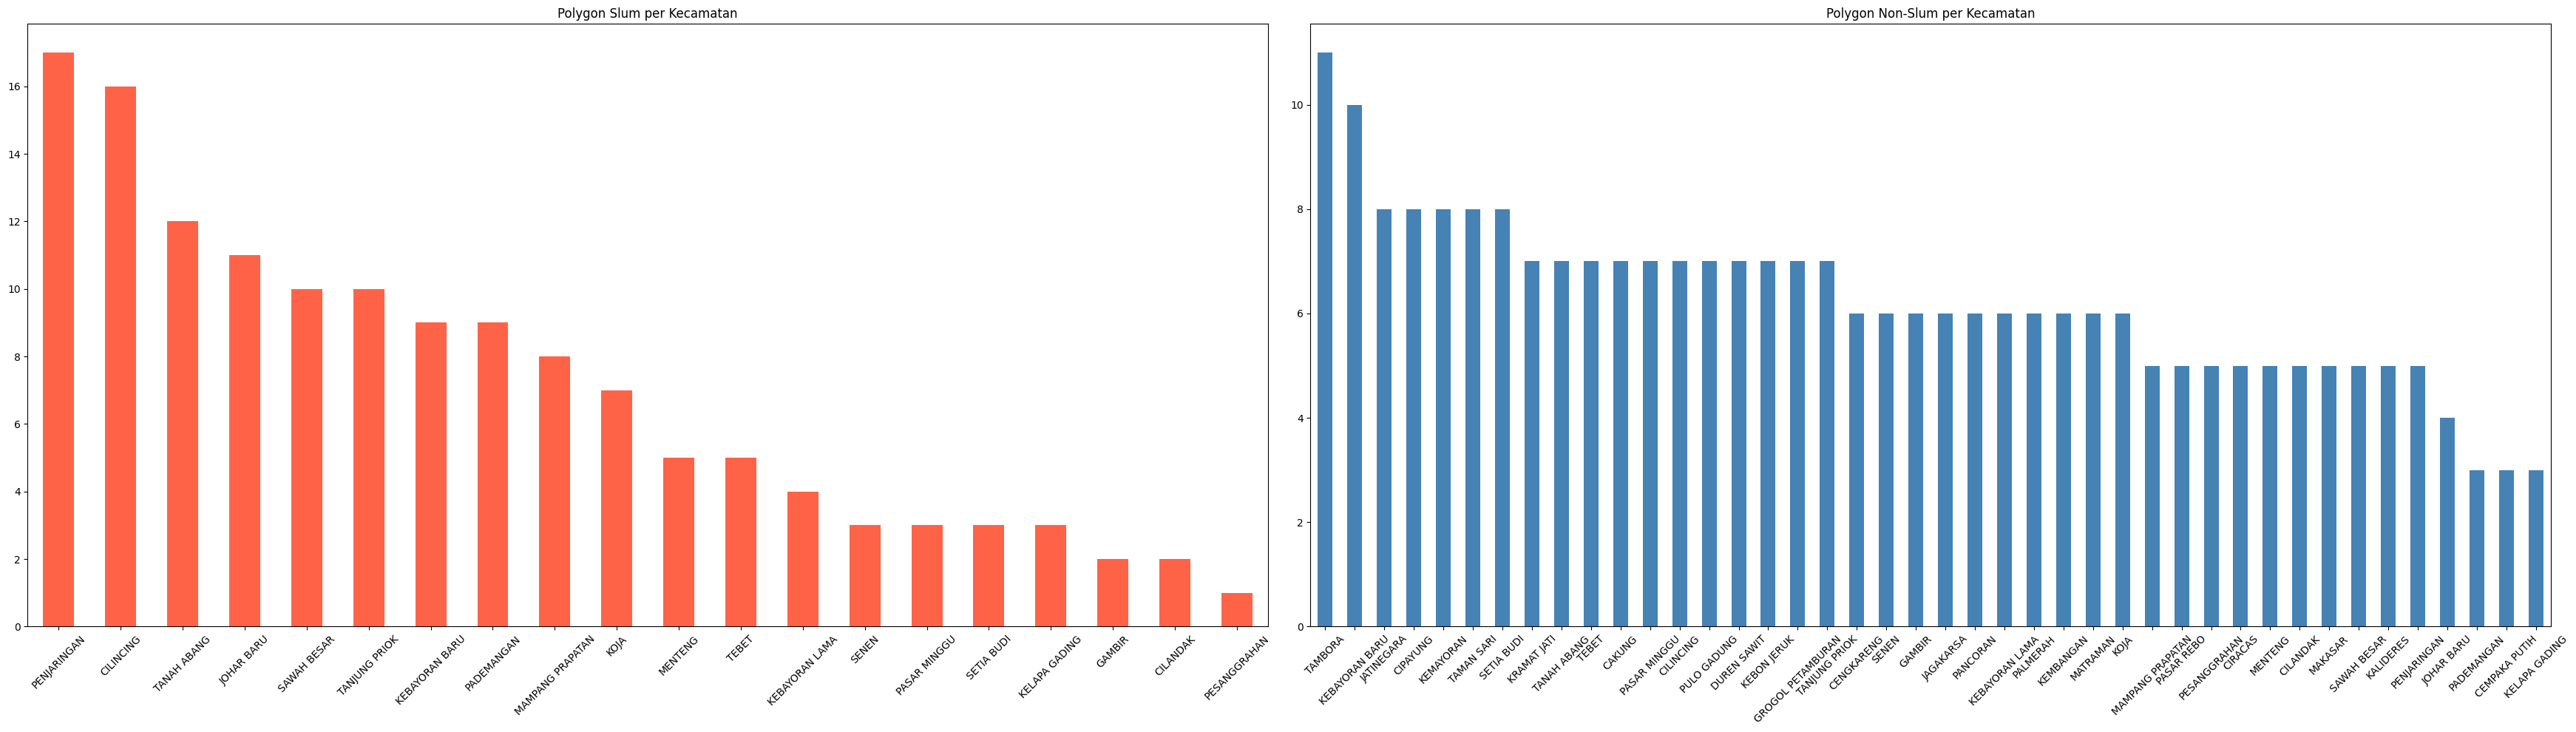

In [27]:
print('=== Distribusi Slum per Kecamatan ===')
slum_kec = gdf_slum['KEC_NAME'].value_counts()
print(slum_kec.to_string())
print(f'\nTotal kecamatan slum: {gdf_slum["KEC_NAME"].nunique()}')

print('\n=== Distribusi Non-Slum per Kecamatan ===')
nslum_kec = gdf_nslum['Kecamatan'].value_counts()
print(nslum_kec.to_string())
print(f'\nTotal kecamatan non-slum: {gdf_nslum["Kecamatan"].nunique()}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(35, 10))
slum_kec.plot(kind='bar', ax=ax1, color='tomato')
ax1.set_title('Polygon Slum per Kecamatan'); ax1.set_xlabel(''); ax1.tick_params(axis='x', rotation=45)
nslum_kec.plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Polygon Non-Slum per Kecamatan'); ax2.set_xlabel(''); ax2.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 2. Preprocessing

Langkah yang **dilewati** karena data sudah dalam kondisi sesuai:
- Koreksi atmosfer: data Level-2A, reflektan permukaan sudah terkoreksi
- Normalisasi: nilai sudah dalam rentang [0, 1]
- Resampling: semua band sudah ~10m/pixel
- Reprojeksi: TIF dan GeoJSON sama-sama EPSG:4326 (diverifikasi eksplisit per file)

Langkah yang **dijalankan**: Validasi CRS → Rasterisasi → Spectral Indices → Patch Extraction

### 2.1 Validasi CRS

In [28]:
def check_crs_all(files, ref_crs, label):
    mismatches = []
    for f in files:
        with rasterio.open(f) as src:
            if src.crs != ref_crs:
                mismatches.append(f'{f.name}: {src.crs}')
    status = 'PASS' if not mismatches else 'FAIL'
    print(f'[{status}] {label}: {len(files)} file, ref={ref_crs}')
    for m in mismatches:
        print(f'  MISMATCH: {m}')

ref_crs = gdf_slum.crs
print(f'Reference CRS  : {ref_crs}')
print(f'GeoJSON slum   : {gdf_slum.crs}')
print(f'GeoJSON non-slum: {gdf_nslum.crs}')
check_crs_all(slum_files,  ref_crs, 'Slum TIF')
check_crs_all(nslum_files, ref_crs, 'Non-slum TIF')

Reference CRS  : EPSG:4326
GeoJSON slum   : EPSG:4326
GeoJSON non-slum: EPSG:4326
[PASS] Slum TIF: 140 file, ref=EPSG:4326
[PASS] Non-slum TIF: 261 file, ref=EPSG:4326


### 2.2 Rasterisasi GeoJSON → Mask Biner

Setiap TIF dipasangkan dengan polygon GeoJSON via FID yang diembedded di nama file (`_ID<n>.tif`).  
Slum: polygon di-rasterize ke piksel 1 (kawasan kumuh), 0 di luar.  
Non-slum: mask seluruhnya 0.

SLUM_ANCOL_RW_01_ID86.tif  →  FID=86  →  ['PADEMANGAN' 'ANCOL' 'RW 01']
SLUM_ANCOL_RW_02_ID87.tif  →  FID=87  →  ['PADEMANGAN' 'ANCOL' 'RW 02']
SLUM_ANCOL_RW_04_ID88.tif  →  FID=88  →  ['PADEMANGAN' 'ANCOL' 'RW 04']


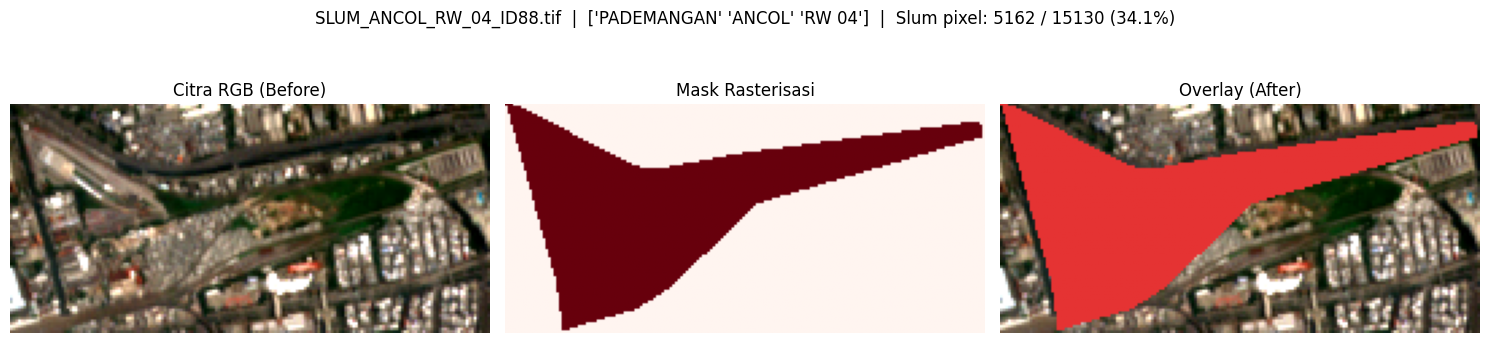

In [29]:
def extract_fid(filename):
    m = re.search(r'_ID(\d+)\.tif$', filename)
    return int(m.group(1)) if m else None

def make_mask(gdf, fid, transform, shape):
    if fid is None:
        return np.zeros(shape, dtype=np.uint8)
    row = gdf[gdf['FID'] == fid]
    if row.empty:
        return np.zeros(shape, dtype=np.uint8)
    geom = row.iloc[0].geometry
    if geom is None or geom.is_empty:
        return np.zeros(shape, dtype=np.uint8)
    return rasterize(
        [(geom.__geo_interface__, 1)],
        out_shape=shape, transform=transform,
        fill=0, dtype=np.uint8
    )

# Verifikasi FID matching
for f in slum_files[:3]:
    fid = extract_fid(f.name)
    row = gdf_slum[gdf_slum['FID'] == fid]
    match_info = row[['KEC_NAME','KEL_NAME','RW']].values[0] if not row.empty else 'TIDAK DITEMUKAN'
    print(f'{f.name}  →  FID={fid}  →  {match_info}')

# Before / After visualization
sample_path = slum_files[2]  # pilih sampel dengan mask yang jelas
with rasterio.open(sample_path) as src:
    assert src.crs == ref_crs, f'CRS mismatch: {src.crs}'
    img   = src.read().astype(np.float32)
    tf    = src.transform
    shape = (src.height, src.width)

fid  = extract_fid(sample_path.name)
mask = make_mask(gdf_slum, fid, tf, shape)

overlay = rgb_stretch(img).copy()
overlay[mask == 1] = [0.9, 0.2, 0.2]  # merah = slum

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(rgb_stretch(img));  axes[0].set_title('Citra RGB (Before)')
axes[1].imshow(mask, cmap='Reds'); axes[1].set_title('Mask Rasterisasi')
axes[2].imshow(overlay);           axes[2].set_title('Overlay (After)')
for ax in axes: ax.axis('off')
row_info = gdf_slum[gdf_slum['FID']==fid][['KEC_NAME','KEL_NAME','RW']].values[0]
plt.suptitle(f'{sample_path.name}  |  {row_info}  |  Slum pixel: {mask.sum()} / {mask.size} ({mask.mean()*100:.1f}%)')
plt.tight_layout()
plt.show()

### 2.3 Spectral Indices

Ditambahkan sebagai channel 7–9 (index 6–8):

| Index | Formula | Interpretasi |
|---|---|---|
| NDVI | (B8−B4)/(B8+B4) | Vegetasi tinggi → negatif di kawasan kumuh padat |
| NDBI | (B11−B8)/(B11+B8) | Tinggi di area bangunan/urban |
| MNDWI | (B3−B11)/(B3+B11) | Tinggi di area air/sungai |

Shape sebelum: (6, 85, 178) → sesudah: (9, 85, 178)
  NDVI: min=-0.214, max=0.813, mean=0.203
  NDBI: min=-0.450, max=0.279, mean=0.029
  MNDWI: min=-0.631, max=0.386, mean=-0.255


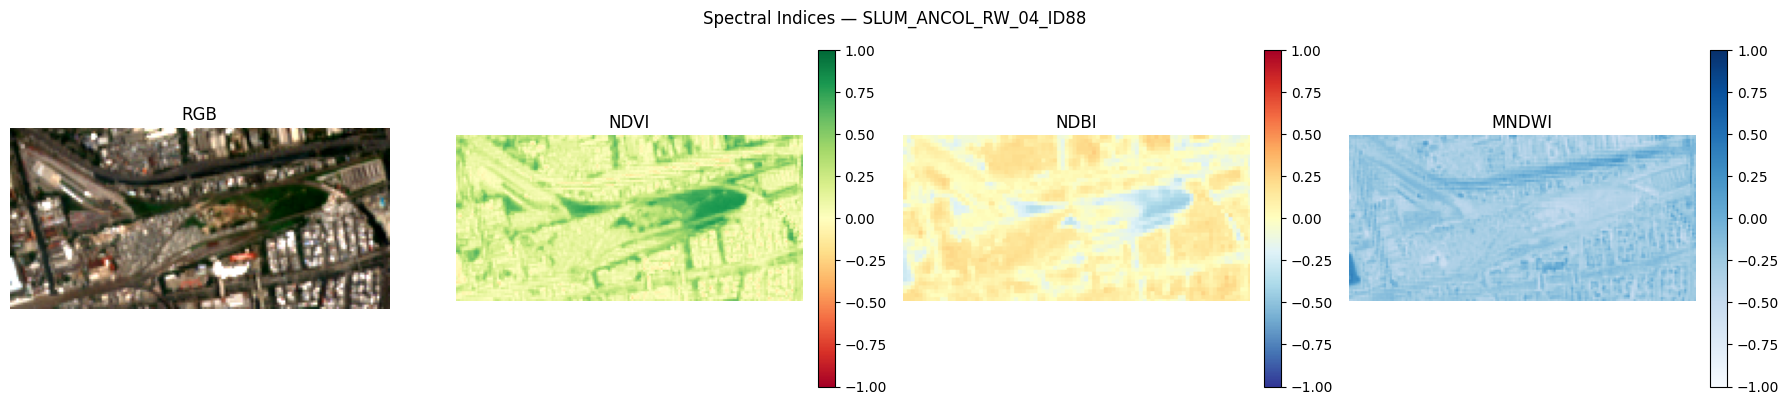

In [30]:
def safe_ratio(a, b):
    d = a + b
    return np.where(d == 0, 0.0, (a - b) / d)

def add_spectral_indices(img):
    """img: (6,H,W) → (9,H,W); append NDVI, NDBI, MNDWI"""
    B3, B4, B8, B11 = img[1], img[2], img[3], img[4]
    ndvi  = safe_ratio(B8,  B4)
    ndbi  = safe_ratio(B11, B8)
    mndwi = safe_ratio(B3,  B11)
    return np.concatenate([img, ndvi[None], ndbi[None], mndwi[None]], axis=0)

img9 = add_spectral_indices(img)
print(f'Shape sebelum: {img.shape} → sesudah: {img9.shape}')
for name, ch in [('NDVI', 6), ('NDBI', 7), ('MNDWI', 8)]:
    v = img9[ch]
    print(f'  {name}: min={v.min():.3f}, max={v.max():.3f}, mean={v.mean():.3f}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(rgb_stretch(img)); axes[0].set_title('RGB'); axes[0].axis('off')

index_cfg = [('NDVI', 6, 'RdYlGn'), ('NDBI', 7, 'RdYlBu_r'), ('MNDWI', 8, 'Blues')]
for ax, (name, ch, cm) in zip(axes[1:], index_cfg):
    im = ax.imshow(img9[ch], cmap=cm, vmin=-1, vmax=1)
    ax.set_title(name); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Spectral Indices — {sample_path.stem}')
plt.tight_layout()
plt.show()

### 2.4 Patch Extraction

Strategi:
- TIF dengan dimensi < 256 di minimal satu sisi → **zero-pad** ke 256×256, hasilkan 1 patch **(selalu disimpan)**
- TIF ≥ 256 px di semua sisi → **sliding window** 256×256 stride=128 (50% overlap), edge ditutup dengan patch terakhir
- Filter valid pixel ratio **hanya** diterapkan pada sliding window patches — padded patches (gambar kecil yang mewakili seluruh image) tidak difilter

Metadata tiap patch (patch_id, source, kecamatan, slum_pixel_ratio) disimpan ke `metadata.csv` untuk Spatial CV.

In [31]:
def get_patch_starts(dim, patch_size, stride):
    if dim <= patch_size:
        return [0]
    starts = list(range(0, dim - patch_size + 1, stride))
    if starts[-1] + patch_size < dim:
        starts.append(dim - patch_size)
    return starts

def extract_patches(image, mask, patch_size, stride, valid_thresh):
    C, H, W = image.shape
    ph = max(0, patch_size - H)
    pw = max(0, patch_size - W)
    # Gambar lebih kecil dari patch_size → akan di-pad → satu patch = seluruh gambar
    needs_pad = ph > 0 or pw > 0
    if ph or pw:
        image = np.pad(image, ((0, 0), (0, ph), (0, pw)), constant_values=0)
        mask  = np.pad(mask,  ((0, ph), (0, pw)),          constant_values=0)
    _, H2, W2 = image.shape
    patches = []
    for y in get_patch_starts(H2, patch_size, stride):
        for x in get_patch_starts(W2, patch_size, stride):
            ip = image[:, y:y+patch_size, x:x+patch_size]
            mp = mask[y:y+patch_size, x:x+patch_size]
            valid_ratio = np.any(ip != 0, axis=0).mean()
            # Padded patches mewakili seluruh gambar kecil → simpan tanpa filter
            if needs_pad or valid_ratio >= valid_thresh:
                patches.append((ip.astype(np.float32), mp.astype(np.uint8)))
    return patches

(PATCH_DIR / 'images').mkdir(parents=True, exist_ok=True)
(PATCH_DIR / 'masks').mkdir(parents=True, exist_ok=True)

meta_rows = []
patch_idx = 0
t0 = time.time()

for fpath in tqdm(slum_files, desc='Slum'):
    with rasterio.open(fpath) as src:
        assert src.crs == ref_crs, f'CRS mismatch: {fpath.name}'
        img_raw = src.read().astype(np.float32)
        tf      = src.transform
        shape   = (src.height, src.width)

    fid = extract_fid(fpath.name)
    row = gdf_slum[gdf_slum['FID'] == fid]
    kec = row.iloc[0]['KEC_NAME'] if not row.empty else 'UNKNOWN'
    msk = make_mask(gdf_slum, fid, tf, shape)
    img9 = add_spectral_indices(img_raw)

    for ip, mp in extract_patches(img9, msk, PATCH_SIZE, STRIDE, VALID_THRESH):
        np.save(PATCH_DIR / 'images' / f'patch_{patch_idx:05d}.npy', ip)
        np.save(PATCH_DIR / 'masks'  / f'mask_{patch_idx:05d}.npy',  mp)
        meta_rows.append({
            'patch_id': patch_idx, 'source': fpath.name,
            'label_class': 'slum', 'kecamatan': kec,
            'valid_ratio': float(np.any(ip != 0, axis=0).mean()),
            'slum_pixel_ratio': float(mp.mean()),
        })
        patch_idx += 1

for fpath in tqdm(nslum_files, desc='Non-slum'):
    with rasterio.open(fpath) as src:
        assert src.crs == ref_crs, f'CRS mismatch: {fpath.name}'
        img_raw = src.read().astype(np.float32)
        shape   = (src.height, src.width)

    fid = extract_fid(fpath.name)
    row = gdf_nslum[gdf_nslum['FID'] == fid]
    kec = row.iloc[0]['Kecamatan'] if not row.empty else 'UNKNOWN'
    msk  = np.zeros(shape, dtype=np.uint8)
    img9 = add_spectral_indices(img_raw)

    for ip, mp in extract_patches(img9, msk, PATCH_SIZE, STRIDE, VALID_THRESH):
        np.save(PATCH_DIR / 'images' / f'patch_{patch_idx:05d}.npy', ip)
        np.save(PATCH_DIR / 'masks'  / f'mask_{patch_idx:05d}.npy',  mp)
        meta_rows.append({
            'patch_id': patch_idx, 'source': fpath.name,
            'label_class': 'non_slum', 'kecamatan': kec,
            'valid_ratio': float(np.any(ip != 0, axis=0).mean()),
            'slum_pixel_ratio': float(mp.mean()),
        })
        patch_idx += 1

meta_df = pd.DataFrame(meta_rows)
meta_df.to_csv(PATCH_DIR / 'metadata.csv', index=False)

print(f'\nSelesai dalam {time.time()-t0:.1f}s')
print(f'Total patch      : {len(meta_df)}')
print(meta_df['label_class'].value_counts().to_string())
slum_with_pixels = (meta_df[meta_df['label_class']=='slum']['slum_pixel_ratio'] > 0).sum()
print(f'Slum patch dengan piksel slum > 0: {slum_with_pixels} / {(meta_df["label_class"]=="slum").sum()}')
ratio = (meta_df['label_class']=='slum').sum() / len(meta_df)
print(f'Rasio slum patch : {ratio:.3f}  (imbalance ratio 1:{(1-ratio)/ratio:.0f})')

Non-slum: 100%|██████████| 261/261 [00:16<00:00, 16.14it/s]



Selesai dalam 22.1s
Total patch      : 677
label_class
non_slum    517
slum        160
Slum patch dengan piksel slum > 0: 160 / 160
Rasio slum patch : 0.236  (imbalance ratio 1:3)


=== Statistik Patch ===
       valid_ratio  slum_pixel_ratio
count   677.000000        677.000000
mean      0.597669          0.016710
std       0.383480          0.060877
min       0.005035          0.000000
25%       0.235657          0.000000
50%       0.664062          0.000000
75%       1.000000          0.000000
max       1.000000          0.472321

Persebaran kecamatan:
label_class        non_slum  slum
kecamatan                        
CAKUNG                   29     0
CEMPAKA PUTIH             3     0
CENGKARENG               17     0
CILANDAK                 12     2
CILINCING                33    17
CIPAYUNG                 21     0
CIRACAS                  13     0
DUREN SAWIT              13     0
GAMBIR                    6     2
GROGOL PETAMBURAN         7     0
JAGAKARSA                19     0
JATINEGARA                9     0
JOHAR BARU                4    11
KALIDERES                22     0
KEBAYORAN BARU           10     9
KEBAYORAN LAMA           11     4
KEBON JE

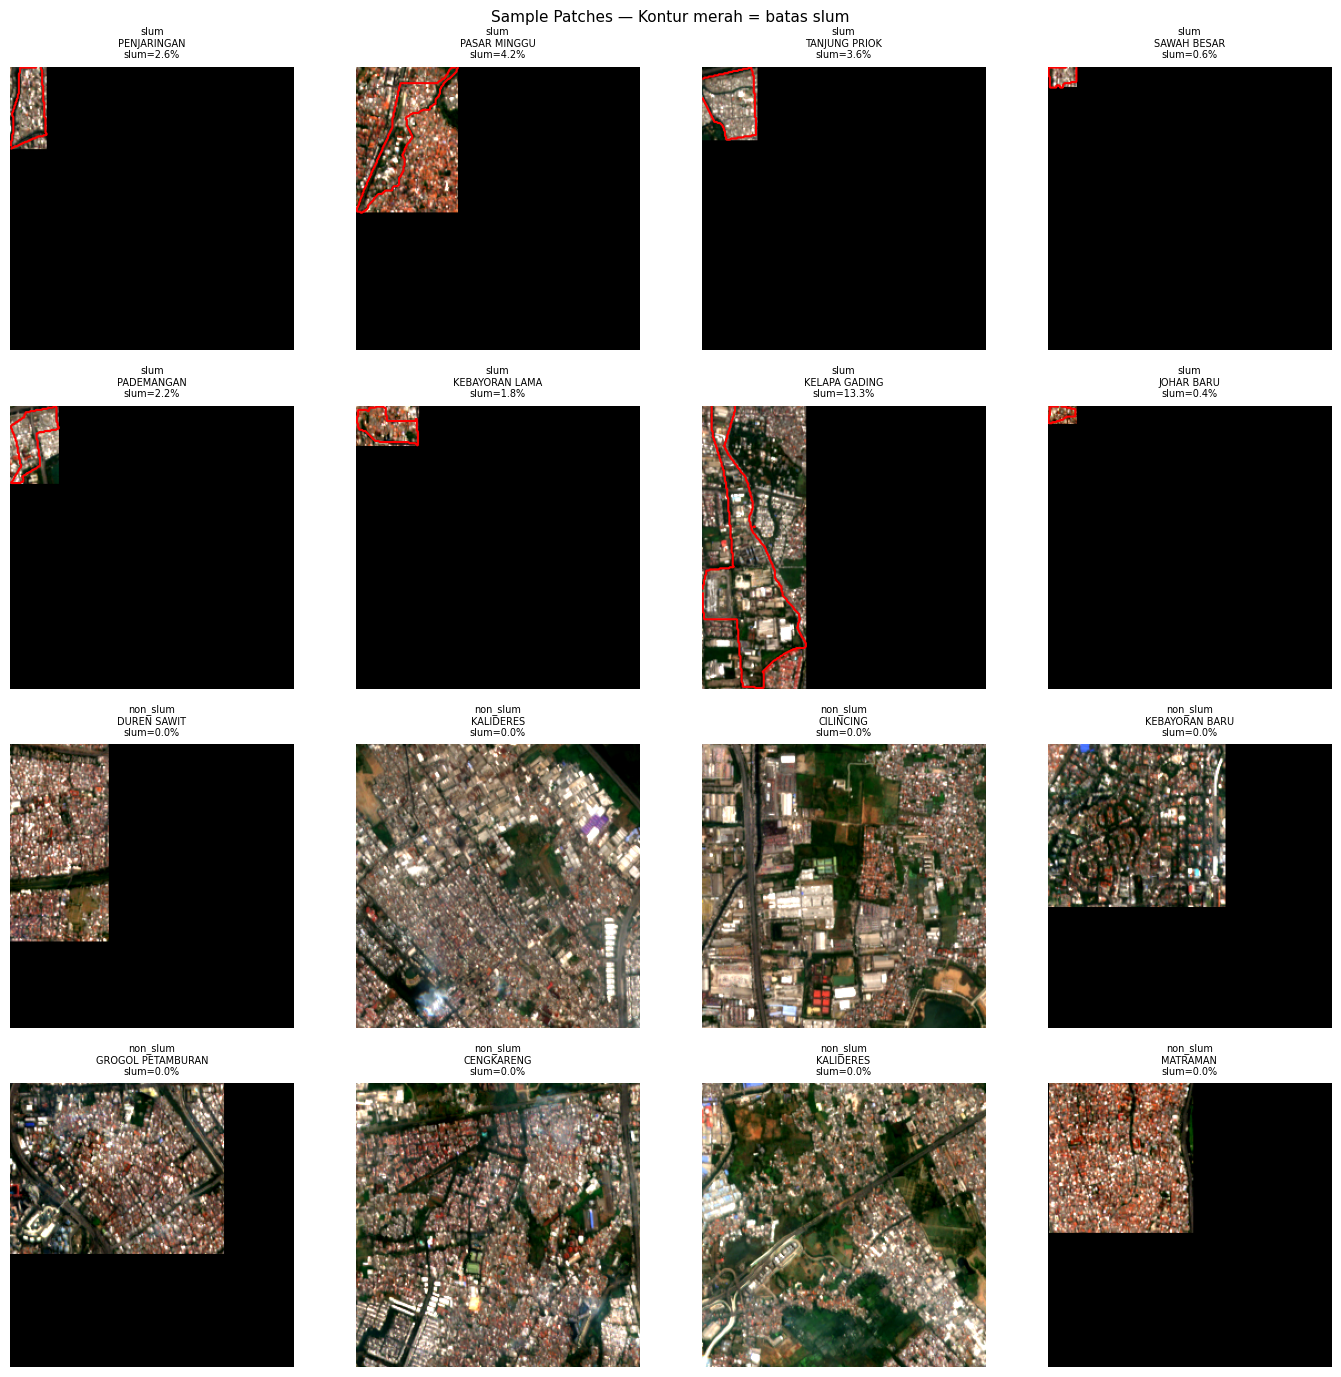

In [32]:
print('=== Statistik Patch ===')
print(meta_df[['valid_ratio', 'slum_pixel_ratio']].describe())
print(f'\nPersebaran kecamatan:')
print(meta_df.groupby(['kecamatan','label_class']).size().unstack(fill_value=0).to_string())

# Sample patches dengan overlay mask
slum_samp  = meta_df[meta_df['label_class']=='slum'].sample(8, random_state=42)
nslum_samp = meta_df[meta_df['label_class']=='non_slum'].sample(8, random_state=42)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for i, (_, row) in enumerate(pd.concat([slum_samp, nslum_samp]).iterrows()):
    pid  = row['patch_id']
    img  = np.load(PATCH_DIR / 'images' / f'patch_{pid:05d}.npy')
    msk  = np.load(PATCH_DIR / 'masks'  / f'mask_{pid:05d}.npy')
    ax   = axes.ravel()[i]
    ax.imshow(rgb_stretch(img))
    if msk.sum() > 0:
        ax.contour(msk, levels=[0.5], colors='red', linewidths=1.5)
    ax.set_title(f"{row['label_class']}\n{row['kecamatan']}\nslum={row['slum_pixel_ratio']*100:.1f}%", fontsize=7)
    ax.axis('off')

plt.suptitle('Sample Patches — Kontur merah = batas slum', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Dataset & Spatial Cross-Validation

Split dilakukan per kecamatan (GroupKFold, 5 fold) untuk mencegah spatial leakage.  
Patch dari kecamatan yang sama selalu berada di fold yang sama — model dievaluasi pada kecamatan yang tidak pernah dilihat saat training.

In [33]:
meta_df = pd.read_csv(PATCH_DIR / 'metadata.csv')
meta_df['kecamatan'] = meta_df['kecamatan'].str.upper().str.strip()

patch_ids = meta_df['patch_id'].values
groups    = meta_df['kecamatan'].values

kfold = GroupKFold(n_splits=5)
folds = list(kfold.split(patch_ids, groups=groups))

print(f'Spatial CV: {len(folds)} fold, split per kecamatan')
print(f'Total kecamatan unik: {meta_df["kecamatan"].nunique()}')
print()
for i, (tr, val) in enumerate(folds):
    val_kec = sorted(set(groups[val]))
    print(f'Fold {i+1}: {len(tr):4d} train | {len(val):4d} val | kecamatan val: {val_kec}')

Spatial CV: 5 fold, split per kecamatan
Total kecamatan unik: 42

Fold 1:  540 train |  137 val | kecamatan val: ['CEMPAKA PUTIH', 'DUREN SAWIT', 'KEBAYORAN LAMA', 'KEMBANGAN', 'MENTENG', 'PADEMANGAN', 'PANCORAN', 'PULO GADUNG']
Fold 2:  542 train |  135 val | kecamatan val: ['CILINCING', 'JATINEGARA', 'JOHAR BARU', 'KEBAYORAN BARU', 'MATRAMAN', 'PESANGGRAHAN', 'SAWAH BESAR', 'SETIA BUDI']
Fold 3:  541 train |  136 val | kecamatan val: ['CENGKARENG', 'GAMBIR', 'KEBON JERUK', 'KOJA', 'PASAR MINGGU', 'PENJARINGAN', 'TAMAN SARI', 'TEBET']
Fold 4:  542 train |  135 val | kecamatan val: ['CAKUNG', 'CILANDAK', 'CIPAYUNG', 'GROGOL PETAMBURAN', 'JAGAKARSA', 'KELAPA GADING', 'KRAMAT JATI', 'PASAR REBO', 'TAMBORA']
Fold 5:  543 train |  134 val | kecamatan val: ['CIRACAS', 'KALIDERES', 'KEMAYORAN', 'MAKASAR', 'MAMPANG PRAPATAN', 'PALMERAH', 'SENEN', 'TANAH ABANG', 'TANJUNG PRIOK']


In [34]:
def geometric_augment(img, mask):
    """img: (C,H,W), mask: (H,W) — random flip + rotate90, applied consistently ke keduanya."""
    if np.random.rand() > 0.5:
        img  = np.flip(img,  axis=2).copy()
        mask = np.flip(mask, axis=1).copy()
    if np.random.rand() > 0.5:
        img  = np.flip(img,  axis=1).copy()
        mask = np.flip(mask, axis=0).copy()
    k = np.random.randint(0, 4)
    if k > 0:
        img  = np.rot90(img,  k, axes=(1, 2)).copy()
        mask = np.rot90(mask, k, axes=(0, 1)).copy()
    return img, mask


class SlumDataset(Dataset):
    def __init__(self, patch_ids, patch_dir, augment=False):
        self.ids     = patch_ids
        self.dir     = Path(patch_dir)
        self.augment = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        pid  = self.ids[idx]
        img  = np.load(self.dir / 'images' / f'patch_{pid:05d}.npy')
        mask = np.load(self.dir / 'masks'  / f'mask_{pid:05d}.npy')
        if self.augment:
            img, mask = geometric_augment(img, mask)
        return (
            torch.tensor(img,  dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32).unsqueeze(0),
        )

# Sanity check
ds_test = SlumDataset(patch_ids[:4], PATCH_DIR)
img_t, mask_t = ds_test[0]
print(f'Image tensor : {img_t.shape}  dtype={img_t.dtype}')
print(f'Mask tensor  : {mask_t.shape}  dtype={mask_t.dtype}')
print(f'Image range  : [{img_t.min():.3f}, {img_t.max():.3f}]')
print(f'Mask unique  : {mask_t.unique().tolist()}')

Image tensor : torch.Size([9, 256, 256])  dtype=torch.float32
Mask tensor  : torch.Size([1, 256, 256])  dtype=torch.float32
Image range  : [-0.631, 0.791]
Mask unique  : [0.0, 1.0]


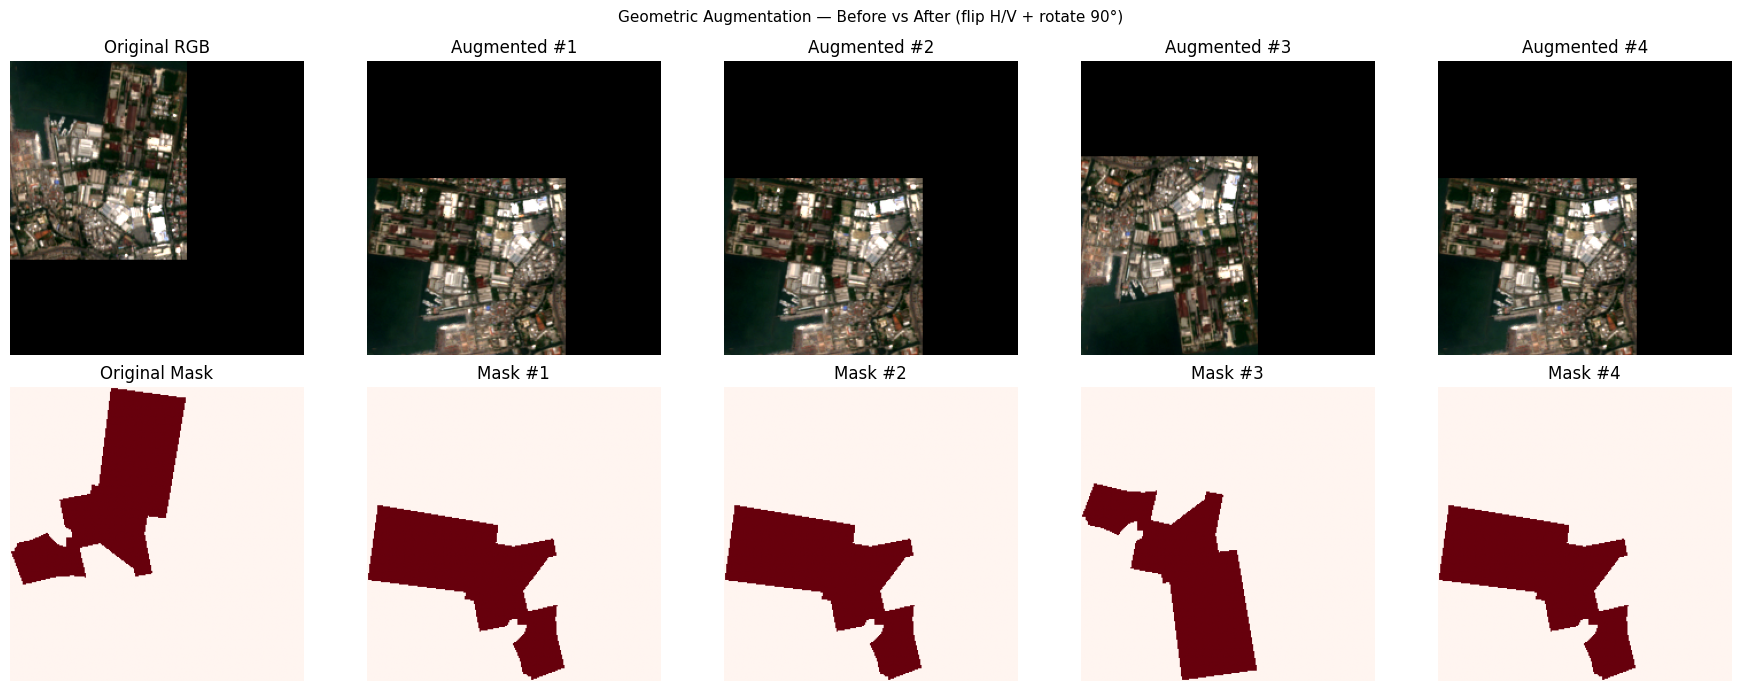

Image dan mask ditransformasi secara konsisten — tidak ada pergeseran antara keduanya.


In [35]:
# Visualisasi augmentasi — before vs after (4 transformasi berbeda pada patch yang sama)
slum_patch_ids = meta_df[meta_df['label_class'] == 'slum']['patch_id'].values
sample_pid = slum_patch_ids[0]

orig_img  = np.load(PATCH_DIR / 'images' / f'patch_{sample_pid:05d}.npy')
orig_mask = np.load(PATCH_DIR / 'masks'  / f'mask_{sample_pid:05d}.npy')

np.random.seed(0)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

axes[0, 0].imshow(rgb_stretch(orig_img));         axes[0, 0].set_title('Original RGB')
axes[1, 0].imshow(orig_mask, cmap='Reds', vmin=0, vmax=1); axes[1, 0].set_title('Original Mask')

for col in range(1, 5):
    aug_img, aug_mask = geometric_augment(orig_img.copy(), orig_mask.copy())
    axes[0, col].imshow(rgb_stretch(aug_img))
    axes[0, col].set_title(f'Augmented #{col}')
    axes[1, col].imshow(aug_mask, cmap='Reds', vmin=0, vmax=1)
    axes[1, col].set_title(f'Mask #{col}')

for ax in axes.ravel():
    ax.axis('off')

plt.suptitle('Geometric Augmentation — Before vs After (flip H/V + rotate 90°)', fontsize=11)
plt.tight_layout()
plt.show()
print('Image dan mask ditransformasi secara konsisten — tidak ada pergeseran antara keduanya.')

## 4. Baseline U-Net

Arsitektur U-Net standar dengan modifikasi:
- Input channel: 9 (6 band asli + NDVI + NDBI + MNDWI)
- Feature map: (32, 64, 128, 256)
- Loss: DiceBCE (kombinasi Binary Cross-Entropy + Dice Loss)
- Optimizer: Adam, LR scheduler: ReduceLROnPlateau
- Early stopping: patience=10
- **Augmentasi geometric diterapkan pada training set** (flip H/V, rotasi 90°/180°/270°)

In [36]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=9, features=(32, 64, 128, 256)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2, 2)
        for f in features:
            self.downs.append(DoubleConv(in_ch, f))
            in_ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.ups.append(DoubleConv(f * 2, f))
        self.head = nn.Conv2d(features[0], 1, 1)

    def forward(self, x):
        skips = []
        for d in self.downs:
            x = d(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            s = skips[-(i // 2 + 1)]
            if x.shape[2:] != s.shape[2:]:
                x = F.interpolate(x, size=s.shape[2:])
            x = self.ups[i + 1](torch.cat([s, x], dim=1))
        return self.head(x)


class DiceBCELoss(nn.Module):
    def forward(self, logits, targets):
        bce   = F.binary_cross_entropy_with_logits(logits, targets)
        p     = torch.sigmoid(logits)
        inter = (p * targets).sum((2, 3))
        dice  = 1 - (2 * inter + 1.0) / (p.sum((2, 3)) + targets.sum((2, 3)) + 1.0)
        return bce + dice.mean()


# Sanity check arsitektur
model_test = UNet().to(DEVICE)
dummy = torch.randn(2, 9, 256, 256).to(DEVICE)
out   = model_test(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {out.shape}')
print(f'Parameter: {sum(p.numel() for p in model_test.parameters()):,}')

Input  : torch.Size([2, 9, 256, 256])
Output : torch.Size([2, 1, 256, 256])
Parameter: 7,764,769


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        total += loss.item() * imgs.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    preds_all, targets_all = [], []
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        total += criterion(logits, masks).item() * imgs.size(0)
        preds_all.append((torch.sigmoid(logits) > 0.5).cpu().numpy().ravel())
        targets_all.append(masks.cpu().numpy().ravel().astype(int))
    p = np.concatenate(preds_all)
    t = np.concatenate(targets_all)
    return {
        'loss': total / len(loader.dataset),
        'IoU': jaccard_score(t, p, zero_division=0),
        'F1':  f1_score(t, p, zero_division=0),
        'OA':  accuracy_score(t, p),
    }


EPOCHS   = 50
LR       = 1e-3
BATCH    = 8
PATIENCE = 10

train_idx0, val_idx0 = folds[0]

# augment=True hanya pada training set
train_loader = DataLoader(SlumDataset(patch_ids[train_idx0], PATCH_DIR, augment=True),
                          batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(SlumDataset(patch_ids[val_idx0],   PATCH_DIR, augment=False),
                          batch_size=BATCH, shuffle=False, num_workers=0)

model     = UNet().to(DEVICE)
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=False)

best_iou      = 0.0
patience_cnt  = 0
history       = []
# Simpan state awal sebagai fallback jika tidak ada improvement sama sekali
best_state    = {k: v.clone() for k, v in model.state_dict().items()}
t0 = time.time()

epoch_bar = tqdm(range(1, EPOCHS + 1), desc='Training Fold 0', unit='epoch')
for epoch in epoch_bar:
    tr_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_m   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_m['loss'])
    history.append({'epoch': epoch, 'train_loss': tr_loss, **val_m})

    if val_m['IoU'] > best_iou:
        best_iou     = val_m['IoU']
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1

    epoch_bar.set_postfix({
        'tr': f'{
            tr_loss:.4f}', 'val': f'{val_m["loss"]:.4f}',
        'IoU': f'{val_m["IoU"]:.4f}', 'best': f'{best_iou:.4f}',
        'p': f'{patience_cnt}/{PATIENCE}',
    })

    if patience_cnt >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

model.load_state_dict(best_state)
torch.save(best_state, PATCH_DIR / 'best_model_fold0.pth')
print(f'\nFold 0 selesai — {time.time()-t0:.0f}s | Best val IoU: {best_iou:.4f}')

Training Fold 0:  44%|████▍     | 22/50 [14:34<18:32, 39.73s/epoch, tr=0.8913, val=1.0940, IoU=0.0407, best=0.0530, p=10/10]


Early stopping at epoch 23

Fold 0 selesai — 874s | Best val IoU: 0.0530


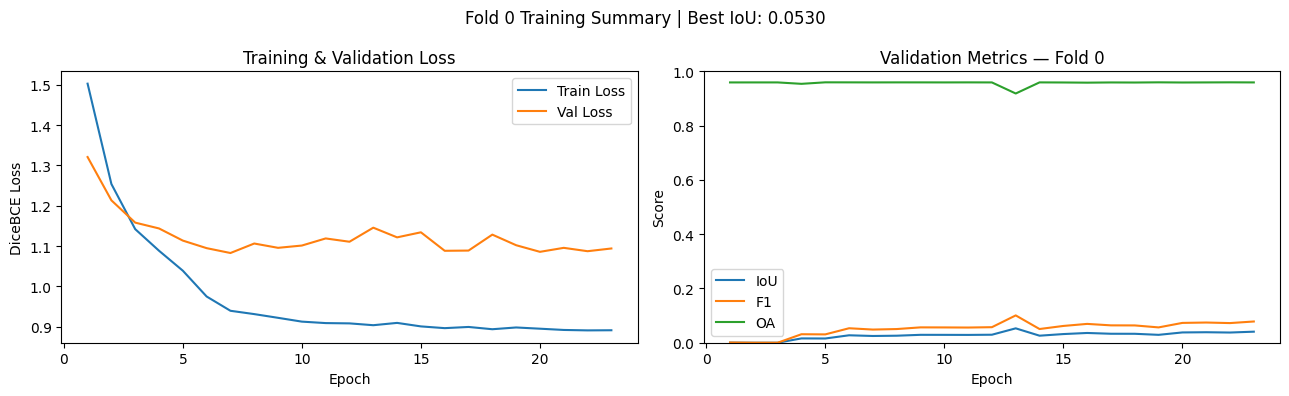

In [38]:
hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss')
ax1.plot(hist_df['epoch'], hist_df['loss'],       label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('DiceBCE Loss'); ax1.legend()
ax1.set_title('Training & Validation Loss')

ax2.plot(hist_df['epoch'], hist_df['IoU'], label='IoU')
ax2.plot(hist_df['epoch'], hist_df['F1'],  label='F1')
ax2.plot(hist_df['epoch'], hist_df['OA'],  label='OA')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score'); ax2.legend()
ax2.set_title('Validation Metrics — Fold 0')
ax2.set_ylim(0, 1)

plt.suptitle(f'Fold 0 Training Summary | Best IoU: {best_iou:.4f}')
plt.tight_layout()
plt.show()

## 5. Spatial Cross-Validation — 5 Fold

Setiap fold melatih model dari nol pada kecamatan training dan mengevaluasi di kecamatan yang tidak pernah dilihat.  
Ini mengukur kemampuan generalisasi spasial model, bukan hanya akurasi in-distribution.

In [39]:
all_fold_results = []

for fold_i, (tr_idx, val_idx) in enumerate(folds):
    val_kec = sorted(set(groups[val_idx]))

    # augment=True hanya pada training set
    tl = DataLoader(SlumDataset(patch_ids[tr_idx],  PATCH_DIR, augment=True),
                    batch_size=BATCH, shuffle=True,  num_workers=0)
    vl = DataLoader(SlumDataset(patch_ids[val_idx], PATCH_DIR, augment=False),
                    batch_size=BATCH, shuffle=False, num_workers=0)

    fm     = UNet().to(DEVICE)
    fopt   = torch.optim.Adam(fm.parameters(), lr=LR)
    fcrit  = DiceBCELoss()
    fsched = torch.optim.lr_scheduler.ReduceLROnPlateau(fopt, patience=5, factor=0.5, verbose=False)

    best_fold_iou = 0.0
    fp_cnt        = 0
    # Simpan state awal sebagai fallback
    best_state    = {k: v.clone() for k, v in fm.state_dict().items()}

    for epoch in range(1, EPOCHS + 1):
        train_epoch(fm, tl, fopt, fcrit, DEVICE)
        vm = evaluate(fm, vl, fcrit, DEVICE)
        fsched.step(vm['loss'])
        if vm['IoU'] > best_fold_iou:
            best_fold_iou = vm['IoU']
            best_state    = {k: v.clone() for k, v in fm.state_dict().items()}
            fp_cnt        = 0
        else:
            fp_cnt += 1
        if fp_cnt >= PATIENCE:
            break

    fm.load_state_dict(best_state)
    final_m = evaluate(fm, vl, fcrit, DEVICE)
    final_m.update({'fold': fold_i + 1, 'val_kecamatan': val_kec, 'epochs_run': epoch})
    all_fold_results.append(final_m)
    print(f'Fold {fold_i+1} | IoU={final_m["IoU"]:.4f} | F1={final_m["F1"]:.4f} | '
          f'OA={final_m["OA"]:.4f} | ep={epoch} | kec={val_kec}')

cv_df = pd.DataFrame(all_fold_results)
print('\n=== Spatial CV Summary ===')
print(cv_df[['fold', 'IoU', 'F1', 'OA']].to_string(index=False))
print()
for m in ['IoU', 'F1', 'OA']:
    print(f'{m}: {cv_df[m].mean():.4f} ± {cv_df[m].std():.4f}')

Fold 1 | IoU=0.1566 | F1=0.2708 | OA=0.9495 | ep=15 | kec=['CEMPAKA PUTIH', 'DUREN SAWIT', 'KEBAYORAN LAMA', 'KEMBANGAN', 'MENTENG', 'PADEMANGAN', 'PANCORAN', 'PULO GADUNG']
Fold 2 | IoU=0.1630 | F1=0.2803 | OA=0.9785 | ep=37 | kec=['CILINCING', 'JATINEGARA', 'JOHAR BARU', 'KEBAYORAN BARU', 'MATRAMAN', 'PESANGGRAHAN', 'SAWAH BESAR', 'SETIA BUDI']
Fold 3 | IoU=0.2559 | F1=0.4075 | OA=0.9837 | ep=38 | kec=['CENGKARENG', 'GAMBIR', 'KEBON JERUK', 'KOJA', 'PASAR MINGGU', 'PENJARINGAN', 'TAMAN SARI', 'TEBET']
Fold 4 | IoU=0.1015 | F1=0.1843 | OA=0.9936 | ep=29 | kec=['CAKUNG', 'CILANDAK', 'CIPAYUNG', 'GROGOL PETAMBURAN', 'JAGAKARSA', 'KELAPA GADING', 'KRAMAT JATI', 'PASAR REBO', 'TAMBORA']
Fold 5 | IoU=0.4081 | F1=0.5797 | OA=0.9943 | ep=28 | kec=['CIRACAS', 'KALIDERES', 'KEMAYORAN', 'MAKASAR', 'MAMPANG PRAPATAN', 'PALMERAH', 'SENEN', 'TANAH ABANG', 'TANJUNG PRIOK']

=== Spatial CV Summary ===
 fold      IoU       F1       OA
    1 0.156574 0.270755 0.949525
    2 0.163014 0.280330 0.978483


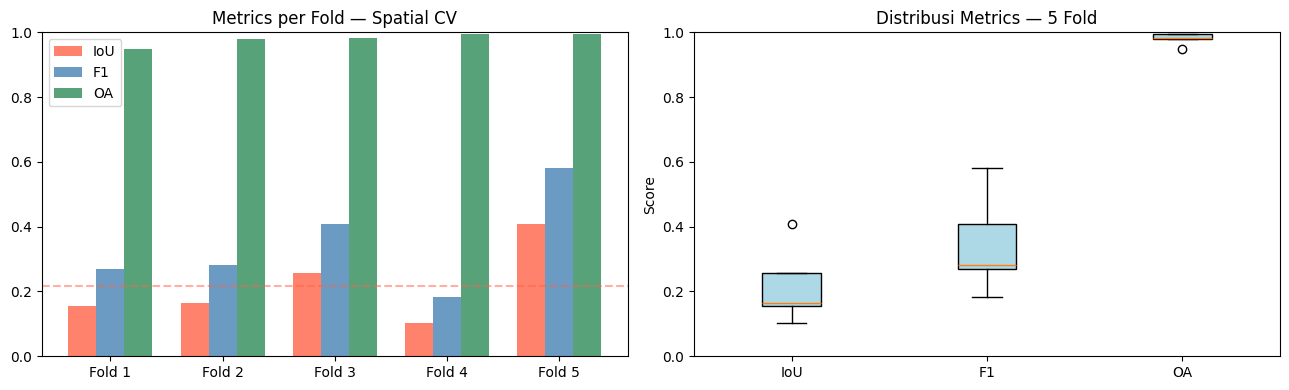


Mean IoU : 0.2170 (target baseline >0.40)
Mean F1  : 0.3445
Mean OA  : 0.9799


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart per fold
metrics = ['IoU', 'F1', 'OA']
x = np.arange(len(cv_df))
w = 0.25
colors = ['tomato', 'steelblue', 'seagreen']
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax1.bar(x + i*w, cv_df[m], w, label=m, color=c, alpha=0.8)
ax1.set_xticks(x + w)
ax1.set_xticklabels([f'Fold {i}' for i in cv_df['fold']])
ax1.set_ylim(0, 1); ax1.legend()
ax1.set_title('Metrics per Fold — Spatial CV')
ax1.axhline(y=cv_df['IoU'].mean(), color='tomato', linestyle='--', alpha=0.5, label='Mean IoU')

# Boxplot summary
ax2.boxplot([cv_df['IoU'], cv_df['F1'], cv_df['OA']], labels=metrics, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax2.set_ylim(0, 1)
ax2.set_title('Distribusi Metrics — 5 Fold')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

print(f'\nMean IoU : {cv_df["IoU"].mean():.4f} (target baseline >0.40)')
print(f'Mean F1  : {cv_df["F1"].mean():.4f}')
print(f'Mean OA  : {cv_df["OA"].mean():.4f}')

## 6. Interpretasi Output

Visualisasi prediksi dibandingkan ground truth pada fold 0 validation set.  
Analisis dilakukan per kecamatan untuk mengidentifikasi pola spasial error.

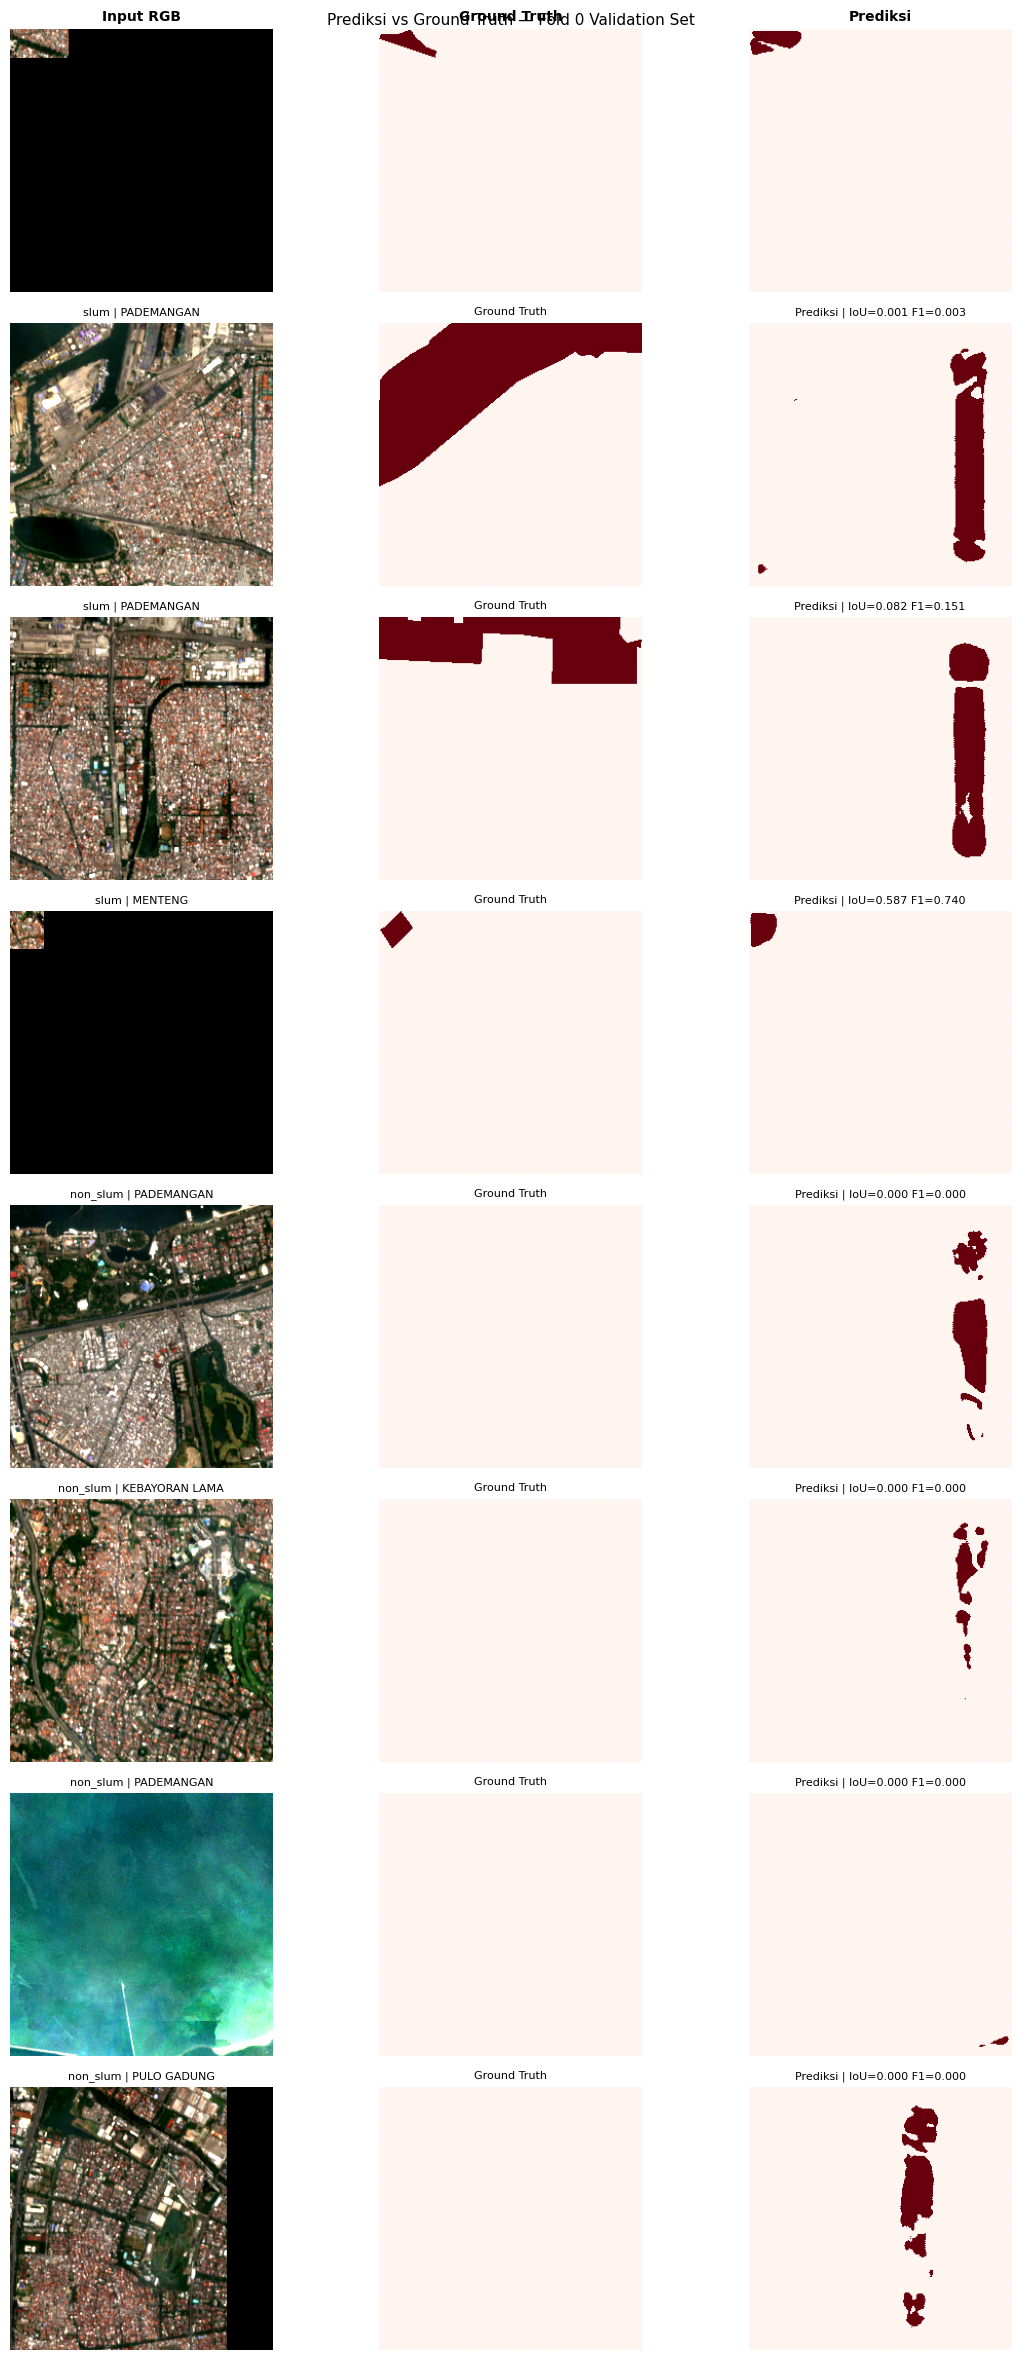

In [41]:
# Load model terbaik fold 0
best_model = UNet().to(DEVICE)
best_model.load_state_dict(torch.load(PATCH_DIR / 'best_model_fold0.pth', map_location=DEVICE))
best_model.eval()

_, val_idx0 = folds[0]
val_meta = meta_df.iloc[val_idx0].reset_index(drop=True)

slum_val   = val_meta[val_meta['label_class']=='slum'].sample(4, random_state=0)
nslum_val  = val_meta[val_meta['label_class']=='non_slum'].sample(4, random_state=0)
samples    = pd.concat([slum_val, nslum_val])

fig, axes = plt.subplots(len(samples), 3, figsize=(12, len(samples)*3))
for row_i, (_, row) in enumerate(samples.iterrows()):
    pid  = row['patch_id']
    img  = np.load(PATCH_DIR / 'images' / f'patch_{pid:05d}.npy')
    msk  = np.load(PATCH_DIR / 'masks'  / f'mask_{pid:05d}.npy')

    with torch.no_grad():
        logit = best_model(torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(DEVICE))
        pred  = torch.sigmoid(logit).squeeze().cpu().numpy()

    pred_bin = (pred > 0.5).astype(np.uint8)
    iou = jaccard_score(msk.ravel(), pred_bin.ravel(), zero_division=0)
    f1  = f1_score(msk.ravel(), pred_bin.ravel(), zero_division=0)

    axes[row_i, 0].imshow(rgb_stretch(img))
    axes[row_i, 0].set_title(f"{row['label_class']} | {row['kecamatan']}", fontsize=8)
    axes[row_i, 1].imshow(msk, cmap='Reds', vmin=0, vmax=1)
    axes[row_i, 1].set_title('Ground Truth', fontsize=8)
    axes[row_i, 2].imshow(pred_bin, cmap='Reds', vmin=0, vmax=1)
    axes[row_i, 2].set_title(f'Prediksi | IoU={iou:.3f} F1={f1:.3f}', fontsize=8)
    for ax in axes[row_i]: ax.axis('off')

for ax, t in zip(axes[0], ['Input RGB', 'Ground Truth', 'Prediksi']):
    ax.set_title(t, fontsize=10, fontweight='bold')

plt.suptitle('Prediksi vs Ground Truth — Fold 0 Validation Set', fontsize=11)
plt.tight_layout()
plt.show()

=== Per-Kecamatan Performance (Fold 0 Validation) ===
     kecamatan  n_patches      IoU       F1       OA
 CEMPAKA PUTIH          3 0.000000 0.000000 0.959615
   DUREN SAWIT         13 0.000000 0.000000 0.933723
     KEMBANGAN         17 0.000000 0.000000 0.949123
   PULO GADUNG          9 0.000000 0.000000 0.943219
      PANCORAN          8 0.000000 0.000000 0.964874
    PADEMANGAN         61 0.062863 0.118290 0.870210
KEBAYORAN LAMA         15 0.075875 0.141049 0.972322
       MENTENG         11 0.218002 0.357966 0.980066


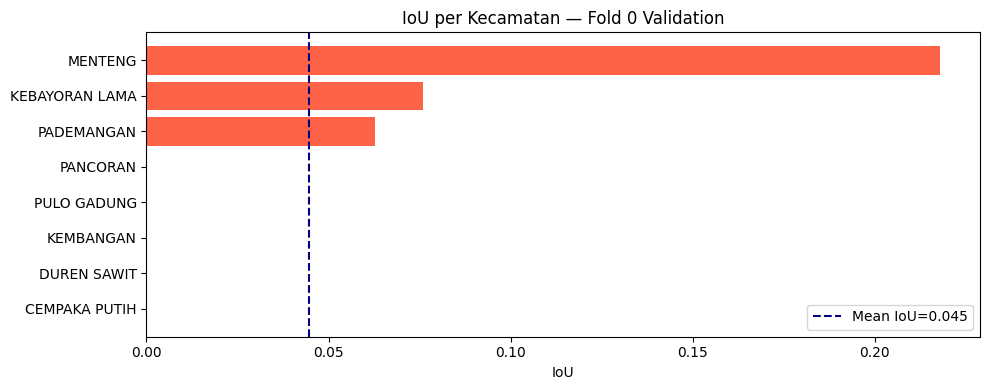

In [42]:
# Per-kecamatan performance — fold 0 validation
kec_metrics = []
val_meta_sorted = val_meta.reset_index(drop=True)

for kec, group in val_meta_sorted.groupby('kecamatan'):
    kec_preds, kec_targets = [], []
    for _, row in group.iterrows():
        pid = row['patch_id']
        img = np.load(PATCH_DIR / 'images' / f'patch_{pid:05d}.npy')
        msk = np.load(PATCH_DIR / 'masks'  / f'mask_{pid:05d}.npy')
        with torch.no_grad():
            logit = best_model(torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(DEVICE))
            pred  = (torch.sigmoid(logit).squeeze().cpu().numpy() > 0.5).astype(int)
        kec_preds.append(pred.ravel())
        kec_targets.append(msk.ravel().astype(int))
    p = np.concatenate(kec_preds)
    t = np.concatenate(kec_targets)
    kec_metrics.append({
        'kecamatan': kec,
        'n_patches': len(group),
        'IoU': jaccard_score(t, p, zero_division=0),
        'F1':  f1_score(t, p, zero_division=0),
        'OA':  accuracy_score(t, p),
    })

kec_df = pd.DataFrame(kec_metrics).sort_values('IoU')
print('=== Per-Kecamatan Performance (Fold 0 Validation) ===')
print(kec_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, max(4, len(kec_df)*0.4)))
colors_bar = ['tomato' if v < 0.3 else 'gold' if v < 0.5 else 'seagreen' for v in kec_df['IoU']]
ax.barh(kec_df['kecamatan'], kec_df['IoU'], color=colors_bar)
ax.axvline(x=kec_df['IoU'].mean(), color='navy', linestyle='--', label=f'Mean IoU={kec_df["IoU"].mean():.3f}')
ax.set_xlabel('IoU'); ax.set_title('IoU per Kecamatan — Fold 0 Validation')
ax.legend()
plt.tight_layout()
plt.show()

### Temuan & Analisis

**Preprocessing:**
- Data Level-2A dengan nilai reflektan [0,1] — pipeline preprocessing dipersingkat signifikan
- Rasterisasi berhasil menghasilkan mask biner per piksel dari polygon GeoJSON
- Distribusi kelas tidak seimbang: terdapat lebih banyak patch non-slum dibanding slum

**Training:**
- Model dilatih dengan Dice+BCE loss yang lebih robust terhadap class imbalance dibanding BCE saja
- ReduceLROnPlateau + early stopping mencegah overfitting pada dataset kecil

**Spatial CV:**
- Variasi IoU antar fold mengindikasikan perbedaan karakteristik spasial tiap kecamatan
- Kecamatan dengan IoU rendah: kemungkinan memiliki pola slum yang berbeda dari distribusi training
- Standard deviation yang tinggi → model sensitif terhadap distribusi spasial training data

**Potensi peningkatan:**
- Data augmentation (flip, rotate, color jitter) untuk meningkatkan generalisasi
- Class weighting atau oversampling pada slum patch
- Arsitektur yang lebih dalam atau pretrained encoder (U-Net++ / DeepLabV3+)
- Post-processing: morphological operations untuk menghaluskan prediksi